# Data Initialization


In [32]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

raw_df = pd.read_csv('weekly_player_stats_offense.csv')
rng = np.random.RandomState(seed=67)

In [33]:
# Holden: initialize labels of features to be used or excluded by model
categorical_features = set([])
real_val_features = set([])
features_dropped = set([]) # remove from lists of kept features
metadata_features = set(['player_id', 'season', 'week'])
target_labels = set(['target_fp_ppr_avg'])

for col in raw_df.columns :
    if pd.api.types.is_numeric_dtype(raw_df[col]) :
        real_val_features.add(col)
    else :
        categorical_features.add(col)
        

In [34]:
# feature + target engineering for RNN
window = 3 # Number of weeks used to formulate rolling averages
raw_df = raw_df.sort_values(['player_id', 'season', 'week']) 
raw_df['target_fp_ppr_avg'] = (
    raw_df.groupby(['player_id', 'season'])['fantasy_points_ppr']
    .transform(lambda x : x.shift(-1).rolling(window=window, min_periods=1).mean())
)


In [35]:
# generate a dataframe to measure feature usability 
rv_stats = []
for col in raw_df[list(real_val_features)].columns: 
    s = raw_df[col]
    t = raw_df['target_fp_ppr_avg']

    mask = s.notna() & t.notna()
    s = s[mask]
    t = t[mask]

    non_nan = mask.mean()
    non_zero = (s != 0).mean()
    std = s.std()

    if std > 0 and t.std() > 0 :
        corr = s.corr(t)
    else :
        corr = np.nan

    rv_stats.append({
        "feature": col,
        "frac_non_nan": non_nan,
        "frac_non_zero": non_zero,
        "std": std,
        "corr_with_target": corr,
        "abs_corr": abs(corr) if pd.notna(corr) else np.nan,
    })

feature_stats = pd.DataFrame(rv_stats) 

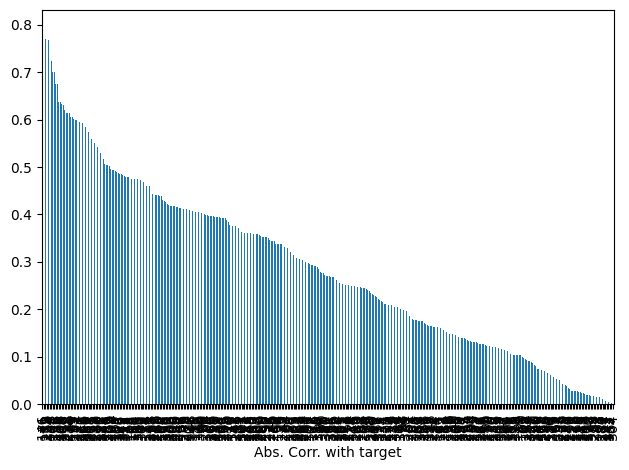

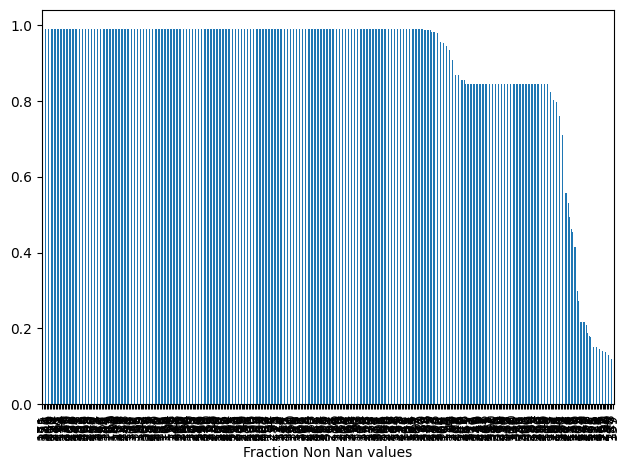

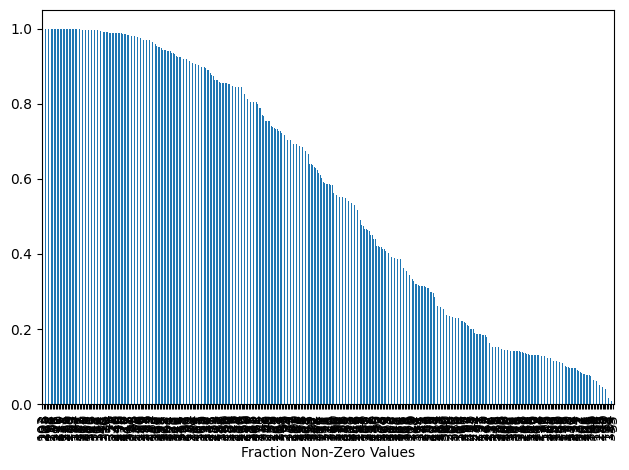

,frac_non_nan,frac_non_zero,std,corr_with_target,abs_corr
count,385.000000,385.000000,385.000000,385.000000,385.000000
mean,0.895754,0.564829,106.974790,0.274875,0.288476
std,0.212271,0.345741,494.859215,0.203015,0.183120
min,0.090484,0.002755,0.027861,-0.405899,0.000807
25%,0.845264,0.201344,0.713804,0.126713,0.132645
50%,0.990738,0.586527,4.010031,0.268201,0.270244
75%,0.990738,0.919430,21.624675,0.411219,0.411219
max,0.990738,1.000000,6048.635106,0.791639,0.791639


In [36]:

feature_stats = feature_stats.sort_values('abs_corr', ascending=False)
feature_stats['abs_corr'].plot(kind='bar')
plt.xlabel("Abs. Corr. with target")
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_nan', ascending=False)
feature_stats['frac_non_nan'].plot(kind='bar')
plt.xlabel('Fraction Non Nan values')
plt.tight_layout()
plt.show()

feature_stats = feature_stats.sort_values('frac_non_zero', ascending=False)
feature_stats['frac_non_zero'].plot(kind='bar')
plt.xlabel("Fraction Non-Zero Values")
plt.tight_layout()
plt.show()
feature_stats.describe()


In [37]:
# cut off any features that are in the bottom 25% of 
# any of the relevance/usability metrics
abs_corr_thresh = feature_stats['abs_corr'].quantile(.25)
non_nan_thresh = feature_stats['frac_non_nan'].quantile(.25)
non_zero_thresh= feature_stats['frac_non_zero'].quantile(.25)

keep_mask = (
    (feature_stats['abs_corr'] >= abs_corr_thresh) &
    (feature_stats['frac_non_nan'] >= non_nan_thresh) &
    (feature_stats['frac_non_zero'] >= non_zero_thresh)
)
keep = feature_stats[keep_mask]['feature'].tolist()
real_val_features.intersection_update(keep)

print(len(real_val_features))


193


In [38]:
# Holden - Commented this out because above code correlation stats removed a large part of features with missing data
# Holden and Connor
# add features with more than missing_threshold% missing data to drop features_list
# temp = raw_df.drop(features_dropped, axis=1)
# missing_values = temp.columns[temp.isnull().any()]
# missing_fractions = raw_df[list(missing_values)].isnull().mean() 

# missing_threshold = missing_fractions.mean()
# features_dropped.update(missing_fractions[missing_fractions > missing_threshold].index)

In [39]:
from sklearn.preprocessing import OneHotEncoder,  StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ensure feature lists are cohesive
for label in features_dropped :
    if label in categorical_features :
        categorical_features.remove(label)
    elif label in real_val_features :
        real_val_features.remove(label)

#real_val_features.difference_update(target_labels) # take potential targets out of features processed by pipeline

# convert to lists so we can stop typcasting 
real_val_features = list(real_val_features) 
categorical_features = list(categorical_features)
target_labels = list(target_labels)
features_dropped = list(features_dropped)


In [40]:
# assume raw_df has a 'season' column and rows are one-week-player records
clean_df = raw_df.drop(columns=list(features_dropped)).copy()

# compute counts per season and cumulative fraction
season_counts = clean_df.groupby('season').size().reset_index(name='count').sort_values('season')
season_counts['cum_count'] = season_counts['count'].cumsum()
total = season_counts['count'].sum()
season_counts['cum_frac'] = season_counts['cum_count'] / total

# pick the last season where cumulative fraction <= target (0.8)
target = 0.8
train_season_cut = season_counts[season_counts['cum_frac'] <= target]['season'].max()

if pd.isna(train_season_cut):
    train_season_cut = season_counts.iloc[(season_counts['cum_frac'] - target).abs().argmin()]['season']

# split
train = clean_df[clean_df['season'] <= train_season_cut].reset_index(drop=True)
test = clean_df[clean_df['season'] > train_season_cut].reset_index(drop=True)

# print how many rows of training and test and what cutoff season was chosen
print(f"chosen train cut season: {train_season_cut}")
print(f"train rows: {len(train)} ({len(train)/len(clean_df):.2%}), test rows: {len(test)} ({len(test)/len(clean_df):.2%})")

# features/target and time index for ordering
X_train = train.drop(columns=['fantasy_points_ppr'])  # adjust target/cols as needed
y_train = train['fantasy_points_ppr']
X_test = test.drop(columns=['fantasy_points_ppr'])
y_test = test['fantasy_points_ppr']

train = train.reset_index(drop=True)
train['time_index'] = np.arange(len(train))

X = clean_df.drop(columns=['fantasy_points_ppr'] + categorical_features)   # features
y = clean_df['fantasy_points_ppr']

tscv = TimeSeriesSplit(n_splits=5)  # or another number of folds
for fold, (train_idx, val_idx) in enumerate(tscv.split(train['time_index'])):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    # fit model on X_tr, y_tr
    # model.fit(X_tr, y_tr)
    # evaluate on X_val, y_val
    # print or log validation metrics for this fold
    
# once hyperparameters chosen, train final model on full train_df and evaluate on test_df
# final_model.fit(X_train, y_train)
# test_pred = final_model.predict(X_test)
# compute test metrics

chosen train cut season: 2021
train rows: 43523 (74.23%), test rows: 15106 (25.77%)


In [41]:

#sort real value features by estimated distribution type
rv_split_std = []
rv_split_skewed = []
rv_split_few = []
for feature in real_val_features :
    column = clean_df[feature]
    unique_vals = column.nunique(dropna=True)

    if unique_vals <= 2 :
        rv_split_few.append(feature)
    else :
        skew = column.skew(skipna=True)
        if abs(skew) > 1 :
            rv_split_skewed.append(feature)
        else :
            rv_split_std.append(feature)

#data preprocessing pipelines
#each distribution gets the appropriate scaler 
#current system expects most values to be skewed 
#   - we may be able to improve our estimation and normalizatioin

# TODO 
# add pipeline for time sorting whole dataframe 
# create pipeline / function to designate past fantasy points as a feature 
# use THIS WEEK to predict NEXT WEEK 
# 
std_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

skewed_pipline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

no_scale_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')) 
])

categorical_pipeline = Pipeline(steps=[
    ('OHE', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(transformers=[
    ('norm_rv', std_pipline, rv_split_std),
    ('skewed_rv', skewed_pipline, rv_split_skewed),
    ('few_rv', no_scale_pipeline, rv_split_few),
    ('categorical', categorical_pipeline, categorical_features)
    ])


# Everything below this point should be model implementation 
## use defined dataframe and preprocessing functions for Builing better model arhcitecture
## Once Time split, feature-target consolidation, and other related preprocessing steps are ready, datasets can be adjusted accordingly

In [42]:
class FantasyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

In [43]:
class MLP_Network(nn.Module) :
    def __init__(self, input_size, hidden_sizes, num_classes, dropout_prob=.2):
        super(MLP_Network, self).__init__()
        self.input_size = input_size
        layers = []
        prev_dim = input_size
        for size in hidden_sizes :
            layers.append(nn.Linear(prev_dim, size))
            layers.append(nn.ReLU())
            if dropout_prob > 0: 
                layers.append(nn.Dropout(dropout_prob))
            prev_dim = size

        layers.append(nn.Linear(prev_dim, num_classes))
        
        self.net = nn.Sequential(*layers)
        self._init_weights()
        
    def _init_weights(self):
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight, nonlinearity='relu')
                nn.init.constant_(layer.bias, 0)

    def forward(self, x) :
        x = x.reshape(-1, self.input_size)
        return self.net(x)

In [44]:
def train_torch_model(model, train_loader, val_loader, num_epochs=100, learning_rate=.001, device='cpu'):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x, y, in val_loader:
                x = x.to(device)
                y = y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if epoch == 25 or epoch == 50 or epoch == 75 or epoch == 100:
            print(f"Epoch: {epoch}'s train loss= {train_loss} and val loss= {val_loss}")

    return model, train_losses, val_losses

def evaluate_torch_model(model, loader, device='cpu'):
    model.eval()
    preds = []
    acts = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            outputs = model(x)
            preds.extend(outputs.cpu().numpy().flatten())
            acts.extend(y.numpy().flatten())

    preds = np.array(preds)
    acts = np.array(acts)

    mse = mean_squared_error(acts, preds)
    r2 = r2_score(acts, preds)

    return mse, r2, preds, acts

In [45]:
# Connor: Code implementation of a Random Forest model that can predict fantasy points based on player stats
# Holden: heavily refined model implementation
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
	
def train_and_evaluate_model(position_df, position_name, use_torch=True) :
	
	X = position_df.drop(columns=target_labels)
	y = position_df['fantasy_points_ppr']
	# TODO 
	# Implement Time sorting pipleine/function
	# Replace standard train test split to split according to time index
	
	X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=.2, random_state=rng)
	
	X_train = preprocess.fit_transform(X_train).toarray()
	X_test = preprocess.transform(X_test).toarray()

	if use_torch:
		train_data = FantasyDataset(X_train, y_train)
		test_data = FantasyDataset(X_test, y_test)

		input_size = X_train.shape[1]
		model = MLP_Network(input_size=input_size, hidden_sizes=[128, 64, 32], num_classes=1, dropout_prob=.2)


		train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
		val_loader = DataLoader(test_data, batch_size=32, shuffle=False)
		model, train_losses, val_losses = train_torch_model(model, train_loader, val_loader, num_epochs=100, learning_rate=.001, device='cpu')

		mse, r2, y_pred, y_actual = evaluate_torch_model(model, val_loader, device='cpu')
	else:
		model = RandomForestRegressor(n_estimators=100, random_state=rng, n_jobs=-1)
		model.fit(X_train, y_train)
		
		y_pred = model.predict(X_test)
		
		mse = mean_squared_error(y_test, y_pred)
		r2 = r2_score(y_test, y_pred)
	
	print(f"Position: {position_name}")
	print(f"Mean Squared Error: {mse}")
	print(f"R^2 Score: {r2}\n")


In [46]:
class FantasyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values if hasattr(y, 'values') else y, dtype=torch.float32).reshape(-1, 1)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

In [47]:

# create seperate datasets for each position
relevant_positions = ['QB', 'RB', 'WR', 'TE']
filtered = clean_df[clean_df['position'].isin(relevant_positions)]
pos_filtered_dfs = {pos : pos_df for pos, pos_df in filtered.groupby('position')}

for position in relevant_positions :
    train_and_evaluate_model(pos_filtered_dfs[position], position)
    



Epoch: 25's train loss= 10.391480540235838 and val loss= 2.0045187373956046
Epoch: 50's train loss= 7.894184631605943 and val loss= 0.8601774300138155
Epoch: 75's train loss= 6.181445346524318 and val loss= 0.8998212075481812
Position: QB
Mean Squared Error: 0.8261855840682983
R^2 Score: 0.9933570027351379

Epoch: 25's train loss= 3.1957811548751085 and val loss= 0.5394705530810864
Epoch: 50's train loss= 2.434697567861765 and val loss= 0.9346828026340362
Epoch: 75's train loss= 1.975485595220581 and val loss= 1.8154079241955534
Position: RB
Mean Squared Error: 2.0918288230895996
R^2 Score: 0.9687361121177673

Epoch: 25's train loss= 2.455800309467893 and val loss= 0.36696037033508566
Epoch: 50's train loss= 1.831024779064845 and val loss= 0.7251891160833425
Epoch: 75's train loss= 1.6248296010452983 and val loss= 0.48907760052845395
Position: WR
Mean Squared Error: 1.438596248626709
R^2 Score: 0.9786286950111389

Epoch: 25's train loss= 3.1565098844794712 and val loss= 1.0673668829600

In [48]:
train_and_evaluate_model(clean_df, 'ALL')

KeyboardInterrupt: 